## Dataset Balancer 
#### Delete images that exceeds the target count

In [3]:
import os
import random

def cleanup_excess_images(base_path, target_count):
    """
    Randomly delete images for classes that exceed the target count.

    Args:
    - base_path (str): Path to the dataset directory containing class folders.
    - target_count (int): Maximum number of images allowed per class.
    """
    for class_dir in filter(lambda d: os.path.isdir(os.path.join(base_path, d)), os.listdir(base_path)):
        class_path = os.path.join(base_path, class_dir)

        all_images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.gif'))]
        current_count = len(all_images)

        print(f"\nProcessing {class_dir}:")
        print(f"Current image count: {current_count}")

        if current_count <= target_count:
            print(f"No deletion required for {class_dir}.")
            continue

        num_to_delete = current_count - target_count
        print(f"Need to delete {num_to_delete} images.")

        augmented_images = [img for img in all_images if '(z' in img]
        deletion_candidates = augmented_images if augmented_images else all_images

        images_to_delete = random.sample(deletion_candidates, num_to_delete)

        for image in images_to_delete:
            image_path = os.path.join(class_path, image)
            os.remove(image_path)

        remaining_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.gif'))])
        print(f"Images after cleanup: {remaining_images}")

if __name__ == "__main__":
    # CHANGE TARGET COUNT DON'T FORGET
    cleanup_excess_images(base_path=r'F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train', target_count=300)


Processing Acacia:
Current image count: 256
No deletion required for Acacia.

Processing Aherns Balok:
Current image count: 453
Need to delete 153 images.
Images after cleanup: 300

Processing Alagao:
Current image count: 268
No deletion required for Alagao.

Processing Alibangbang:
Current image count: 349
Need to delete 49 images.
Images after cleanup: 300

Processing Amugis:
Current image count: 292
No deletion required for Amugis.

Processing Antipolo:
Current image count: 228
No deletion required for Antipolo.

Processing Apitong:
Current image count: 236
No deletion required for Apitong.

Processing Asis:
Current image count: 339
Need to delete 39 images.
Images after cleanup: 300

Processing Balayong:
Current image count: 177
No deletion required for Balayong.

Processing Balete:
Current image count: 288
No deletion required for Balete.

Processing Balongeta:
Current image count: 360
Need to delete 60 images.
Images after cleanup: 300

Processing Banaba:
Current image count: 25

## Data Count After Cleanup

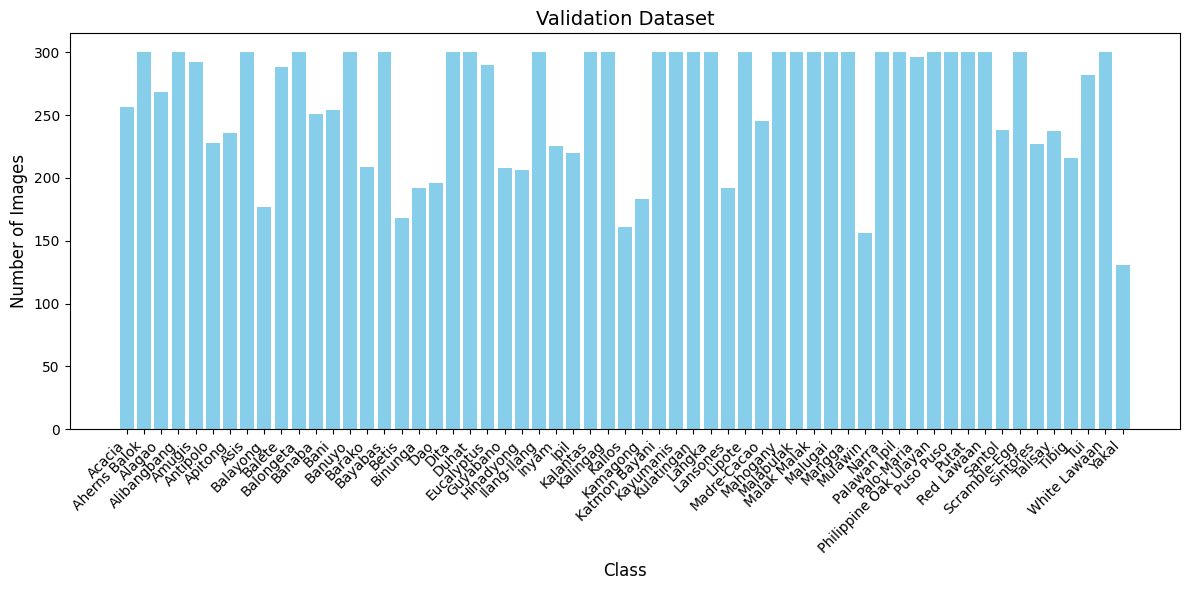

In [4]:
import os
import matplotlib.pyplot as plt

def count_images_per_class(base_path):
    """
    Count images directly inside class folders.

    Args:
    - base_path (str): Path to the dataset directory containing class folders.

    Returns:
    - dict: A dictionary mapping class names to their image counts.
    """
    return {
        class_name: len([f for f in os.listdir(os.path.join(base_path, class_name))
                         if os.path.isfile(os.path.join(base_path, class_name, f))
                         and f.lower().endswith(('.jpg', '.jpeg', '.png', '.gif'))])
        for class_name in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, class_name))
    }

def plot_class_distribution(class_counts):
    """
    Plot a bar chart showing the number of images per class.
    """
    sorted_counts = dict(sorted(class_counts.items()))

    plt.figure(figsize=(12, 6))
    plt.bar(sorted_counts.keys(), sorted_counts.values(), color="skyblue")
    plt.xlabel("Class", fontsize=12)
    plt.ylabel("Number of Images", fontsize=12)
    plt.title("Validation Dataset", fontsize=14)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    train_dir = r"F:\SNAPFOLIA\CLS_DS_59 - SPLIT\train"
    class_counts = count_images_per_class(train_dir)
    plot_class_distribution(class_counts)
